Testing Model

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
data = sns.load_dataset("tips")

In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [64]:
data.describe(include= "all")

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [65]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


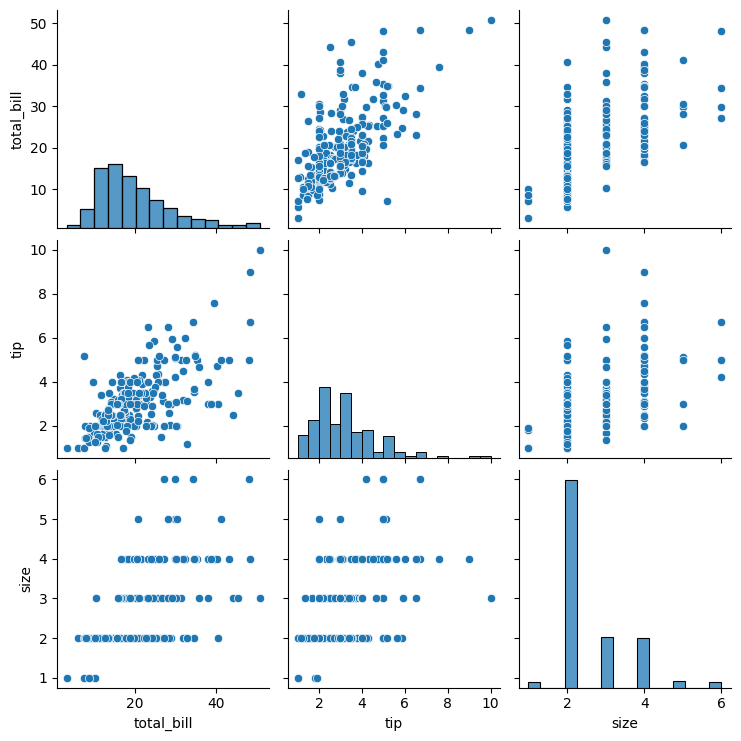

In [66]:
sns.pairplot(data)

## **Features Engineering**

In [67]:
# interations features
# data["tip_ratio_to_bill_total"] = data["tip"] / data["total_bill"]
# data["tip_ratio_to_size"] = data["tip"]**2 / data["size"]
# data["size_ratio_to_bill_total"] = data["size"] / data["total_bill"]
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## **Data Preprocessing**

In [68]:
# null values
missing_values = data.isnull().sum()
missing_values

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [69]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data.smoker = encoder.fit_transform(data.smoker)
data.day = encoder.fit_transform(data.day)
data.time = encoder.fit_transform(data.time)
data["gender"] = encoder.fit_transform(data.sex)
data = data.drop("sex", axis=1)
data

,total_bill,tip,smoker,day,time,size,gender
0,16.99,1.01,0,2,0,2,0
1,10.34,1.66,0,2,0,3,1
2,21.01,3.50,0,2,0,3,1
3,23.68,3.31,0,2,0,2,1
4,24.59,3.61,0,2,0,4,0
...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,0,3,1
240,27.18,2.00,1,1,0,2,0
241,22.67,2.00,1,1,0,2,1
242,17.82,1.75,0,1,0,2,1


In [70]:
data.describe()

,total_bill,tip,smoker,day,time,size,gender
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,0.381148,1.741803,0.278689,2.569672,0.643443
std,8.902412,1.383638,0.486667,0.926815,0.449276,0.951100,0.479967
min,3.070000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,13.347500,2.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,17.795000,2.900000,0.000000,2.000000,0.000000,2.000000,1.000000
75%,24.127500,3.562500,1.000000,3.000000,1.000000,3.000000,1.000000
max,50.810000,10.000000,1.000000,3.000000,1.000000,6.000000,1.000000


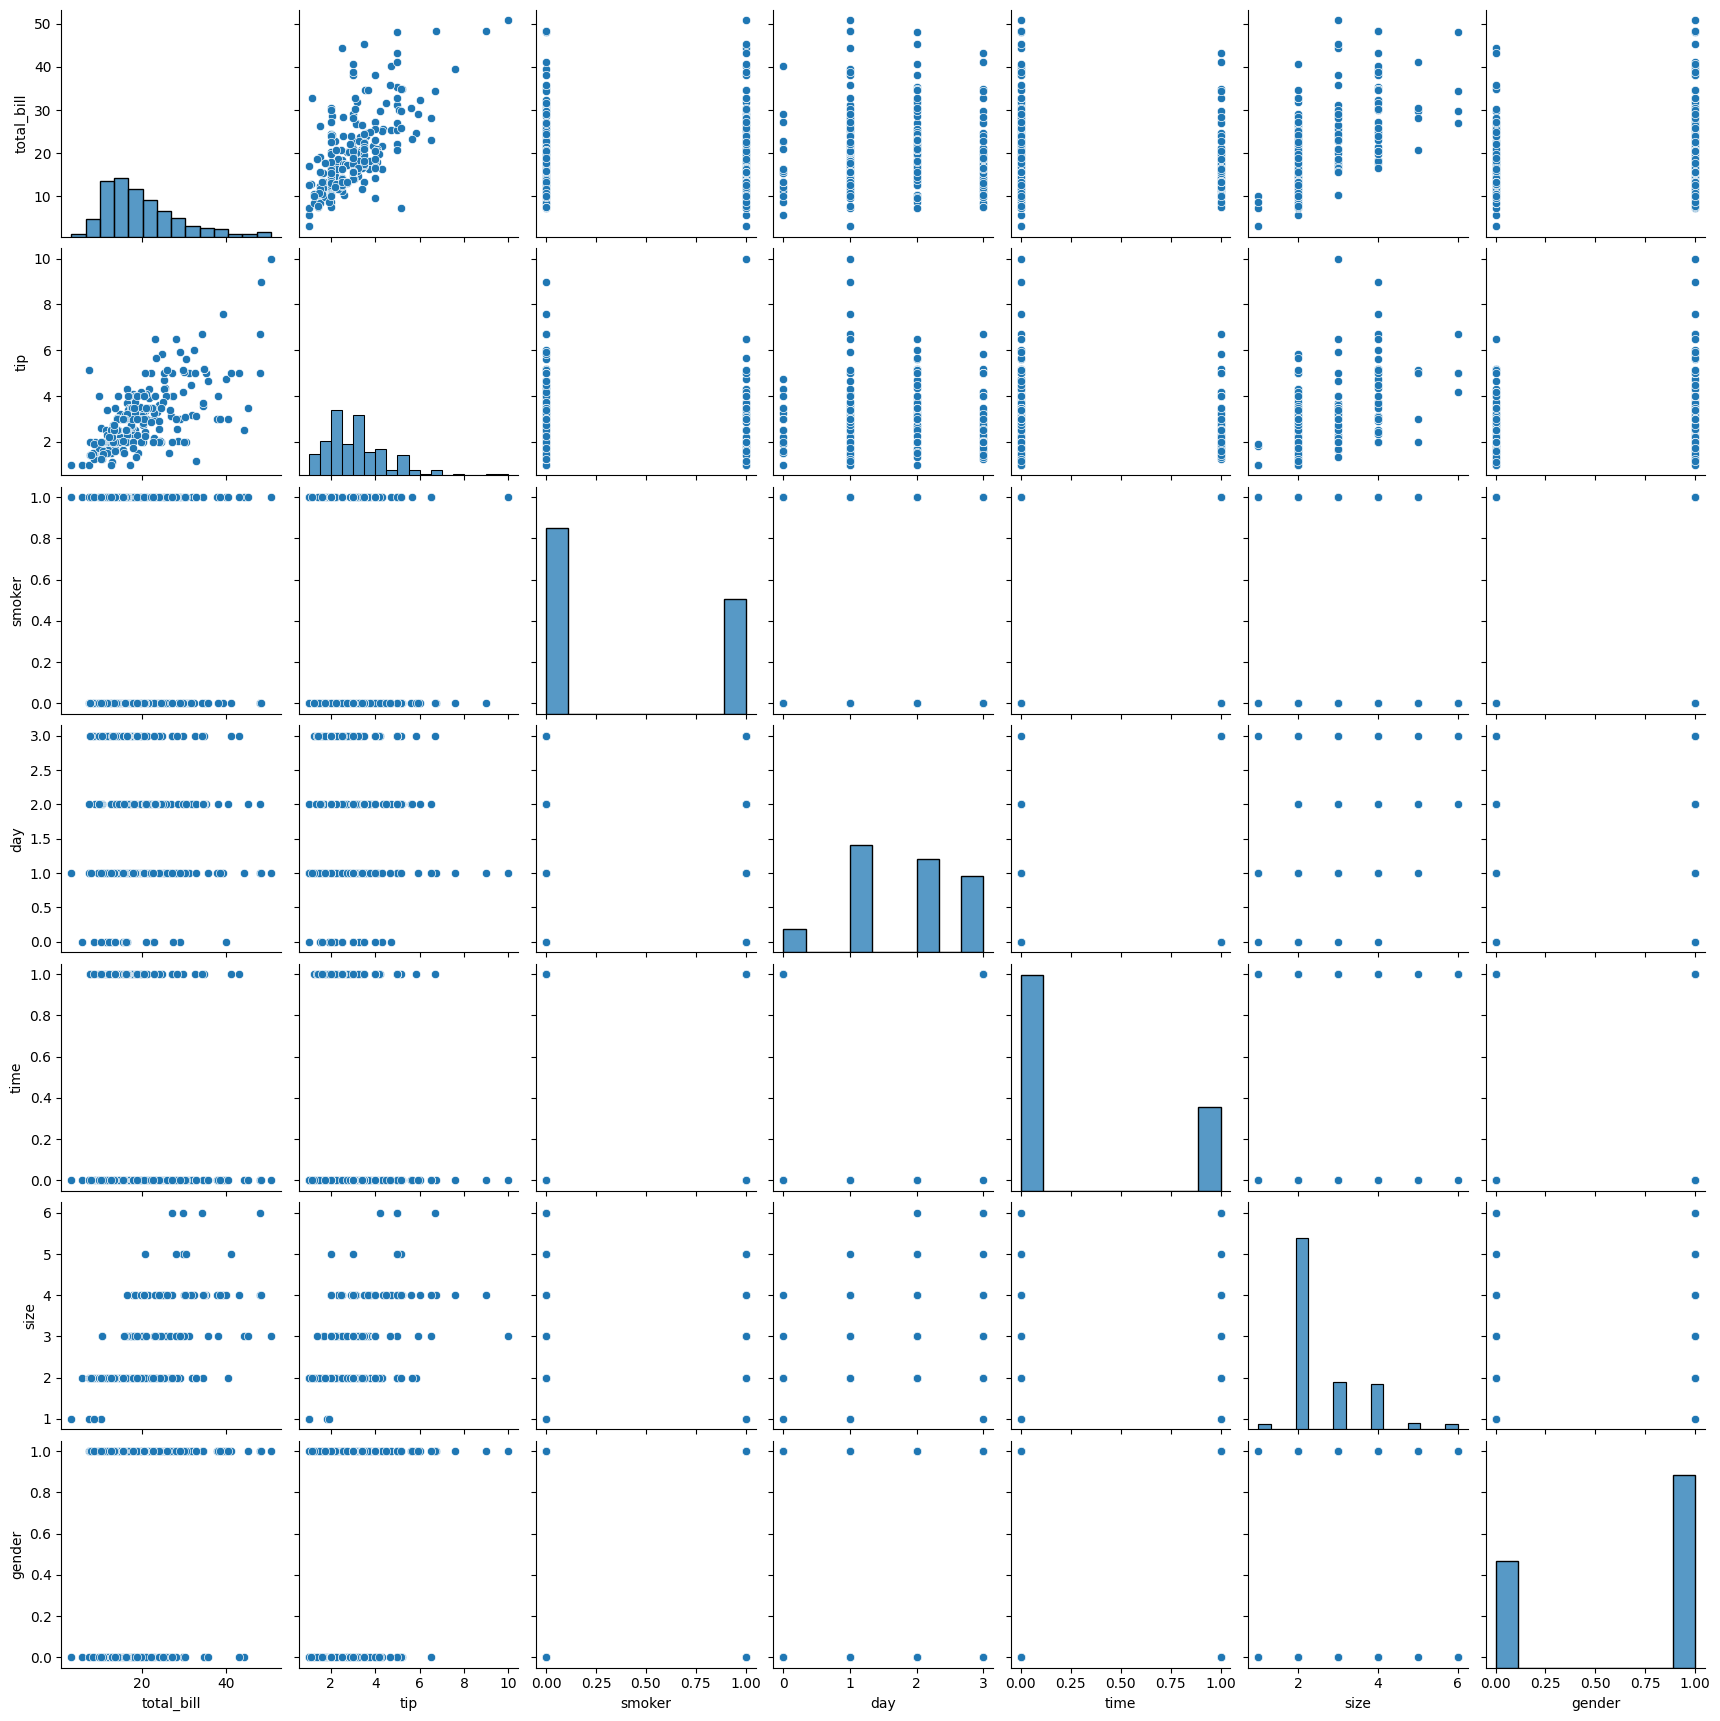

In [ ]:
sns.pairplot(data);

<Axes: >

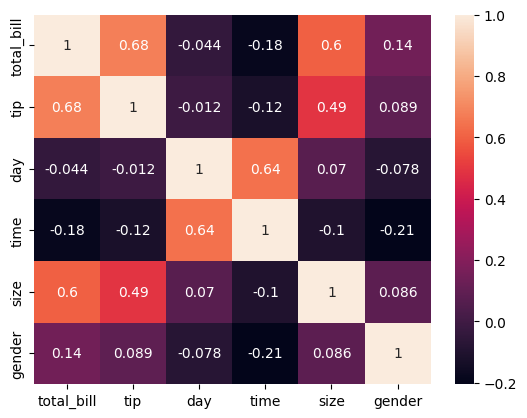

In [72]:
sns.heatmap(data.drop("smoker", axis=1).corr(), annot=True)

In [73]:
x = data.drop("tip", axis =1)
y= data.tip

In [134]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression": Ridge(alpha=10, max_iter=10000),
    "LASSO Regression": Lasso(alpha=100, max_iter=10000),
   # "Support Vector Machine": SVR(kernel='linear'),
  #  "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5),
    #"Random Forest Regressor": RandomForestRegressor(n_estimators=100),
   # "LightGBM": LGBMRegressor(verbose=-1),
  #  "CatBoost": CatBoostRegressor(verbose=0)
}

In [139]:
models_scoures = {}
predictions = {}

for model_name, model in models.items():

    scores_rmse = []
    scores_mae = []
    y_preds = []
    for train_index, test_index in KFold(n_splits=5).split(x,y):
        x_train, x_test = x.loc[train_index], x.loc[test_index]
        y_train, y_test = y[train_index] , y[test_index]
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_preds.append(y_pred)
        scores_rmse.append(mean_squared_error(y_test, y_pred))
        scores_mae.append(mean_absolute_error(y_test, y_pred))


    predictions[model_name] = y_preds
    models_scoures[model_name] = [np.mean(scores_mae) , np.mean(scores_rmse)]
    print(f"{model_name} MAE : {np.mean(scores_mae)}")
    print(f"{model_name} RMSE : {np.mean(scores_rmse)}\n")


Linear Regression MAE : 0.787695302857203
Linear Regression RMSE : 1.122081658584124

Ridge Regression MAE : 0.7805363490732422
Ridge Regression RMSE : 1.1020086156947178

LASSO Regression MAE : 1.0425117608581895
LASSO Regression RMSE : 1.9239219035570045



In [140]:
baseline = np.full_like(y, fill_value= y.mean())

baseline_rmse = np.sqrt(mean_squared_error(y,baseline))
baseline_mae = mean_absolute_error(y,baseline)
print(f"Baseline MAE: {baseline_mae}\nBaseline RMSE: {baseline_rmse}")

Baseline MAE: 1.0330186777747916
Baseline RMSE: 1.3807999538298954


In [127]:
for model_name, model in models.items():
    print(f"{models[model_name]} MAE - Baseline MAE = {models_scoures[model_name][0] - baseline_mae} ")
    print(f"{models[model_name]} RMSE - Baseline RMSE = {models_scoures[model_name][1] - baseline_mae}\n")

LinearRegression(positive=True) MAE - Baseline MAE = -0.2581759641327571 
LinearRegression(positive=True) RMSE - Baseline RMSE = 0.04484899413589183

Ridge(alpha=10, max_iter=10000, positive=True) MAE - Baseline MAE = -0.2625763199331026 
Ridge(alpha=10, max_iter=10000, positive=True) RMSE - Baseline RMSE = 0.037436283939972226

Lasso(alpha=100, max_iter=10000, positive=True) MAE - Baseline MAE = 0.009493083083397913 
Lasso(alpha=100, max_iter=10000, positive=True) RMSE - Baseline RMSE = 0.8909032257822129



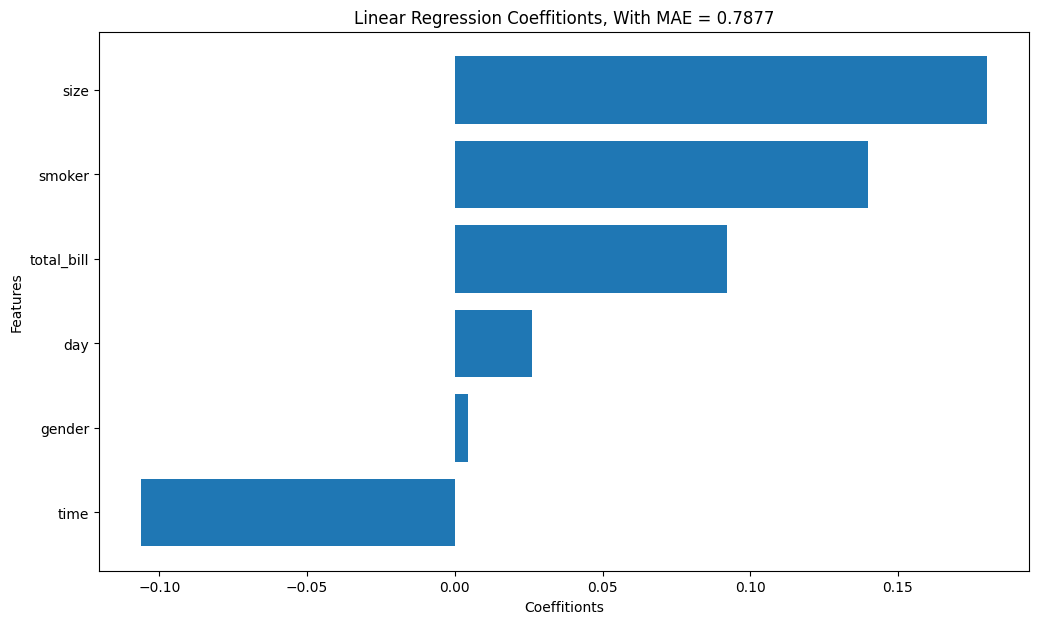

In [136]:
lasso_model = models["Linear Regression"]

lasso_features_and_coef = sorted( list(zip(x.columns, lasso_model.coef_) ) ,key=lambda x: x[1] , reverse= False)
features, coeffitionts = zip(*lasso_features_and_coef)

plt.figure(figsize= (12,7))
plt.barh(features, coeffitionts);
plt.title(f"Linear Regression Coeffitionts, With MAE = {models_scoures["Linear Regression"][0]:.4f}")
plt.xlabel("Coeffitionts")
plt.ylabel("Features")
plt.show()


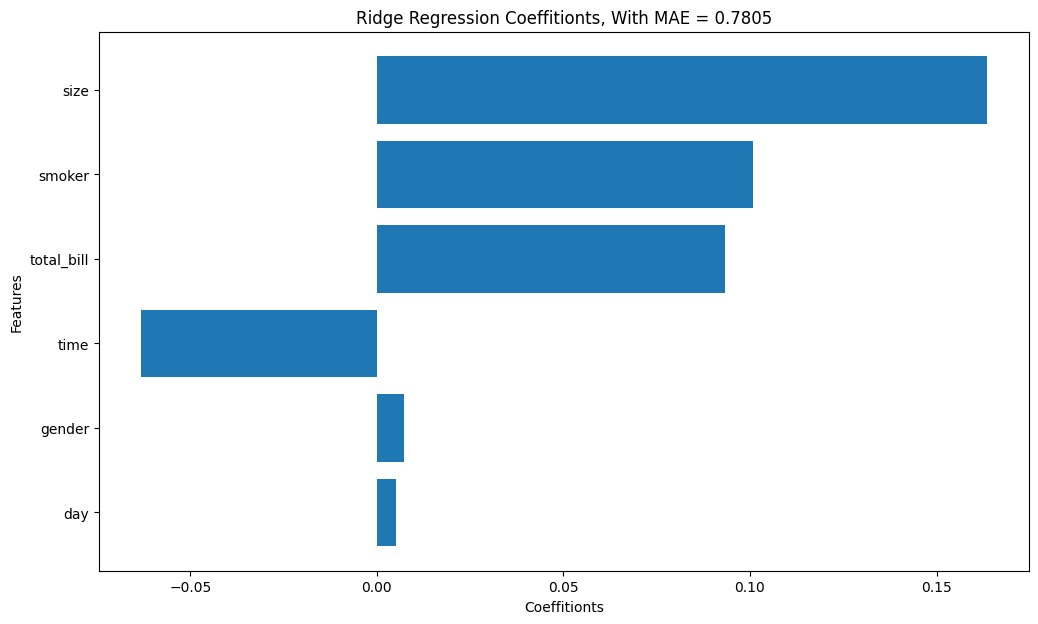

In [138]:
lasso_model = models["Ridge Regression"]

lasso_features_and_coef = sorted( list(zip(x.columns, lasso_model.coef_)) ,key=lambda x: abs(x[1]) , reverse= False)

features, coeffitionts = zip(*lasso_features_and_coef)

plt.figure(figsize= (12,7))
plt.barh(features, coeffitionts);
plt.title(f"Ridge Regression Coeffitionts, With MAE = {models_scoures["Ridge Regression"][0]:.4f}")
plt.xlabel("Coeffitionts")
plt.ylabel("Features")
plt.show()

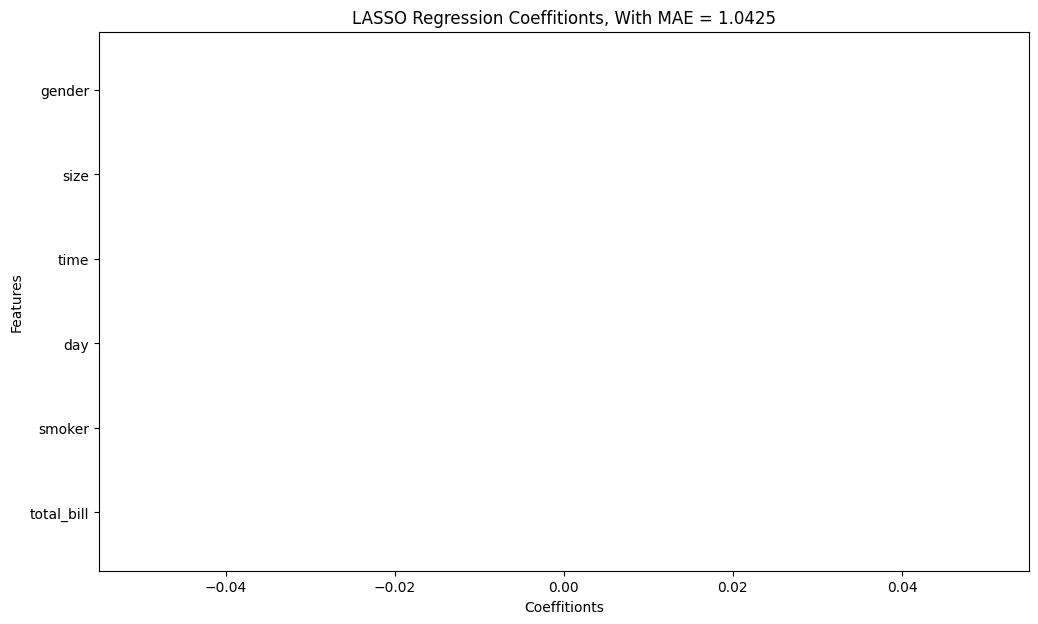

In [137]:
lasso_model = models["LASSO Regression"]

lasso_features_and_coef = sorted( list(zip(x.columns, lasso_model.coef_)) ,key=lambda x: abs(x[1]) , reverse= False)

features, coeffitionts = zip(*lasso_features_and_coef)

plt.figure(figsize= (12,7))
plt.barh(features, coeffitionts);
plt.title(f"LASSO Regression Coeffitionts, With MAE = {models_scoures["LASSO Regression"][0]:.4f}")
plt.xlabel("Coeffitionts")
plt.ylabel("Features")
plt.show()
